<a href="https://www.kaggle.com/code/mudasarsabir/titanic-competition-by-ada-boost?scriptVersionId=237539920" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🏆 Leveraging AdaBoost for Advanced Classification: Titanic Survival Prediction

In this comprehensive guide, we will explore the process of developing and optimizing an **AdaBoost Classifier** for predicting passenger survival in the **Titanic dataset**. Through the implementation of a robust machine learning pipeline, we will utilize various features to predict survival outcomes, focusing on model performance, evaluation, and optimization strategies.


# 0.1: Importing Essential Libraries for AdaBoost Classification

In this section, we import the core libraries required for data preprocessing, building an **AdaBoost Classification** model, evaluating its performance, and visualizing the results.

### Core Libraries
- **`numpy`**:  
  A foundational package for numerical computing, providing support for arrays and mathematical functions.

- **`pandas`**:  
  A powerful data manipulation library, ideal for handling structured data in the form of DataFrames.

### Visualization Libraries
- **`matplotlib.pyplot`**:  
  A comprehensive library for generating static, animated, and interactive visualizations.

- **`seaborn`**:  
  Built on top of `matplotlib`, it offers a high-level interface for attractive statistical graphics.  
  - `sns.set()`: Applies a modern and clean theme for improved plot readability.

  *Note: Use the `%matplotlib inline` directive for inline plots in Jupyter Notebooks.*

### Scikit-Learn: Evaluation Metrics
- **`accuracy_score`**:  
  Calculates the proportion of correctly predicted instances.

- **`f1_score`**:  
  The harmonic mean of precision and recall, providing a balanced evaluation, especially for imbalanced datasets.

- **`recall_score`**:  
  Measures the ability of the model to identify all positive instances.

- **`precision_score`**:  
  Measures the correctness of positive predictions made by the model.

- **`confusion_matrix`**:  
  Summarizes prediction results, including true/false positives and true/false negatives.

- **`classification_report`**:  
  Summarizes key classification metrics (precision, recall, F1-score) for each class.

- **`roc_curve`**:  
  Plots the trade-off between the true positive rate and false positive rate at various thresholds.

- **`auc`**:  
  Computes the Area Under the ROC Curve (AUC), a key performance metric.

- **`roc_auc_score`**:  
  Directly calculates the AUC score from predicted probabilities.

- **`make_scorer`**:  
  Allows the use of custom metrics during model evaluation.

### Scikit-Learn: Models and Utilities
- **`DecisionTreeClassifier`**:  
  A tree-based classifier that splits data at each node based on feature values.

- **`RandomForestClassifier`**:  
  An ensemble of decision trees designed to improve model accuracy and reduce overfitting.

- **`AdaBoostClassifier`**:  
  An ensemble method that combines multiple weak classifiers (typically decision trees) to create a strong classifier.

- **`train_test_split`**:  
  Splits data into training and testing sets for model validation.

- **`from sklearn import tree`**:  
  Provides utilities for visualizing decision trees and analyzing tree-based models.

- **`compute_class_weight`**:  
  Computes class weights to handle class imbalance during model training.

These libraries and functions are the foundation for building a robust machine learning pipeline that integrates decision tree-based models with ensemble methods like AdaBoost and Random Forests.


In [1]:
# =======================
#     Import Libraries
# =======================

# --- Core Libraries ---
import numpy as np
import pandas as pd

# --- Visualization Libraries ---
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for consistent plots
sns.set()

# --- Scikit-Learn Components ---

# Metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
    make_scorer
)

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Model Selection
from sklearn.model_selection import train_test_split

# Utilities
from sklearn import tree  # For visualizing decision trees
from sklearn.utils.class_weight import compute_class_weight

# Uncomment if running in Jupyter Notebook
%matplotlib inline

# 0.2: Plotting the ROC Curve and Calculating AUC

This section defines a reusable function to plot the ROC (Receiver Operating Characteristic) curve and compute the AUC (Area Under the Curve) for a given set of actual labels and predicted probabilities.

### 📈 Function: `plot_roc_curve()`
This function visualizes the model's classification performance across different thresholds and highlights the decision point closest to a threshold of 0.5.

### Parameters:
- **`y_actual_values`** *(np.ndarray)*:  
  The ground truth labels for the classification task (e.g., 0s and 1s).

- **`predicted_probability`** *(np.ndarray)*:  
  The predicted probabilities of the positive class output by the model (usually from `.predict_proba()` or `.decision_function()`).

### Key Steps:
1. **Compute ROC Curve Metrics**  
   Uses `roc_curve()` to calculate:
   - **FPR**: False Positive Rate
   - **TPR**: True Positive Rate (Recall)
   - **Thresholds**: Probability thresholds at which these metrics were calculated

2. **Compute AUC Score**  
   Uses `roc_auc_score()` to calculate a single summary value that represents the overall quality of the classifier.

3. **Plot the ROC Curve**  
   - Plots the ROC curve (TPR vs. FPR) with the AUC score in the legend
   - Plots a diagonal dashed red line representing a random guess classifier
   - Highlights the point on the curve corresponding to the threshold closest to **0.5**, typically used in binary classification

4. **Display the Plot**  
   Adds axis labels, a title, and a legend for clarity.


In [2]:
def plot_roc_curve(
    y_actual_values: np.ndarray, 
    predicted_probability: np.ndarray, 
    title: str = " "
) -> None:
    """
    Plots the ROC curve and displays the AUC for a binary classifier.

    Parameters
    ----------
    y_actual_values : np.ndarray
        Ground truth binary labels (0 or 1).
    
    predicted_probability : np.ndarray
        Predicted probabilities for the positive class (class 1).

    title : str, optional
        Title for the plot. Default is " ".

    Returns
    -------
    None
        Displays the ROC curve plot.
    """
    # Calculate False Positive Rate, True Positive Rate, and thresholds
    fpr, tpr, thresholds = roc_curve(y_actual_values, predicted_probability)
    
    # Compute Area Under the Curve
    auc_score = roc_auc_score(y_actual_values, predicted_probability)

    # Initialize plot
    plt.figure(figsize=(8, 8))
    plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')

    # Highlight the point closest to threshold = 0.5
    closest_idx = np.argmin(np.abs(thresholds - 0.5))
    plt.scatter(
        fpr[closest_idx], tpr[closest_idx],
        color='lightgreen', edgecolors='red', s=100,
        label=f'Threshold ≈ 0.5 (T={thresholds[closest_idx]:.2f})'
    )

    # Format plot
    plt.title(title + ' Receiver Operating Characteristic (ROC) (AUC) Curve')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xticks(np.round(np.arange(0, 1.05, 0.05), 2), rotation=90)
    plt.yticks(np.round(np.arange(0, 1.05, 0.05), 2))
    plt.grid(True)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()


# 0.3: Generating a Complete Classification Report and Evaluation Summary

In this section, we define a utility function `evaluate_model_performance()` to display a comprehensive set of evaluation metrics and visual summaries for binary classification models. This function streamlines model assessment by combining multiple reporting elements into a single step.

### 🧠 Function: `evaluate_model_performance()`
This function outputs key classification metrics including the classification report, confusion matrix (with labeled cells), accuracy, precision, recall, F1 score, as well as True Positive Rate (TPR) and False Positive Rate (FPR). These metrics are essential for understanding a model’s strengths and weaknesses.

---

### 📥 Parameters:
- **`y_actual_values`** *(array-like)*:  
  The actual (true) labels from the test set.

- **`predictions`** *(array-like)*:  
  The predicted labels generated by the classifier.

---

### 📤 Outputs:
- **Classification Report**:  
  Displays precision, recall, F1-score, and support for each class.

- **Labeled Confusion Matrix**:  
  Shows counts of:
  - True Positives (TP)
  - False Positives (FP)
  - False Negatives (FN)
  - True Negatives (TN)

- **Evaluation Metrics**:
  - **Accuracy**: Overall correctness of the classifier.
  - **Precision**: Correctness of positive predictions.
  - **Recall (Sensitivity / TPR)**: Coverage of actual positive cases.
  - **F1 Score**: Harmonic mean of precision and recall.

- **TPR (True Positive Rate)**:  
  Measures how effectively the model identifies positive samples.  
  **Formula**: `TPR = TP / (TP + FN)`

- **FPR (False Positive Rate)**:  
  Measures how often negative samples are incorrectly labeled as positive.  
  **Formula**: `FPR = FP / (FP + TN)`

  

In [3]:
def evaluate_model_performance(y_actual_values, predictions, predicted_probabilities):
    """
    This function generates a comprehensive classification report, confusion matrix, and key evaluation metrics 
    for binary classification models, including accuracy, precision, recall, F1 score, True Positive Rate (TPR),
    and False Positive Rate (FPR).
    
    Args:
    y_actual_values (array-like): The actual labels from the test set.
    predictions (array-like): The predicted labels from the classifier.

    Outputs:
    - Classification report.
    - Confusion matrix and its elements.
    - Evaluation metrics (Accuracy, Precision, Recall, F1 Score).
    - True Positive Rate (TPR) and False Positive Rate (FPR).

    return:
    -accuracy
    -precision
    -recall
    -f1_score_
    
    """

    # Compute Area Under the Curve
    auc_score = roc_auc_score(y_actual_values, predicted_probabilities)
    
    # Classification Report
    print('\n [--Classification Report--] \n')
    print(classification_report(y_actual_values, predictions))
    
    # Confusion Matrix and elements
    tn, fp, fn, tp = confusion_matrix(y_actual_values, predictions).ravel()
    
    # Confusion Matrix Display
    print('\n [----Confusion Matrix-----] \n')
    print(pd.DataFrame({"pred_Survived (TP/FP)": ['TP ' + str(tp), 'FP ' + str(fp)], 
                        "pred_Not Survived (FN/TN)": ['FN ' + str(fn), 'TN ' + str(tn)]},
                       index=["Survived", "Not Survived"]), '\n')
    
    # Metrics Calculation
    print('\n [---------Metrics---------] \n')
    accuracy = accuracy_score(y_actual_values, predictions)
    precision = precision_score(y_actual_values, predictions)
    recall = recall_score(y_actual_values, predictions)
    f1_score_ = f1_score(y_actual_values, predictions)
    
    print("Accuracy:         ", accuracy)
    print("Precision:        ", precision)
    print("Recall:           ", recall)
    print("F1 Score:         ", f1_score_)
    print("Area Under Curve: ", auc_score)
    
    # TPR and FPR Calculation
    tpr = tp / (fn + tp)
    fpr = fp / (fp + tn)
    
    print("\n------------------------------ \n\nHigher TPR (True Positive Rate) is better!")
    print("TPR measures how many of the actual positive cases (actual 'Yes') were correctly predicted as positive ('Yes').")
    print("In other words, it tells us how well the model captures true positive cases (sensitivity).")
    print("\nFormula (TPR = TP / (TP + FN))")
    print("\n(True Positive Rate) TPR: %0.3f%%" % (tpr * 100), '\n\n------------------------------')
    
    print("\nLower FPR (False Positive Rate) is better!")
    print("It measures the proportion of actual negative cases ('No') that were incorrectly predicted as positive ('Yes').")
    print("\nFormula (FPR = FP / (TN + FP))")
    print("\n(False Positive Rate) FPR: %0.3f%%" % (fpr * 100), '\n\n------------------------------')

    return accuracy, precision, recall, f1_score_, auc_score


# 0.4 📊 plot_bar_chart Function Description

The `plot_bar_chart` function is designed to generate a professional and customizable bar chart using Seaborn and Matplotlib. It is ideal for visualizing feature importance or any other comparison between categorical and numerical data.

### 🔧 Parameters

- **`dataframe`** (`pd.DataFrame`):  
  The input DataFrame containing the data to plot.

- **`x_label`** (`str`):  
  The name of the column to be displayed on the x-axis (e.g., feature names).

- **`y_label`** (`str`):  
  The name of the column to be displayed on the y-axis (e.g., importance scores).

- **`title`** (`str`):  
  The main title of the plot. The phrase "Feature Importance" is automatically appended.

- **`color`** (`str`, optional):  
  The color of the bars. Default is `'b'` (blue).

- **`figsize`** (`tuple`, optional):  
  The size of the plot in inches. Default is `(10, 5)`.

- **`xlabel_text`** (`str`, optional):  
  Custom label for the x-axis. If not provided, defaults to the value of `x_label`.

- **`ylabel_text`** (`str`, optional):  
  Custom label for the y-axis. If not provided, defaults to the value of `y_label`.

- **`rotation`** (`int`, optional):  
  The rotation angle for x-axis labels to improve readability. Default is `90` degrees.

### 📤 Returns

- **None**  
  This function directly displays the bar chart and does not return any value.

### ✅ Example Use Case

This function is commonly used to visualize feature importance values returned from machine learning models . It helps identify which features contribute the most to predictions in an interpretable way.



## 1: Loading and Preparing the Titanic Dataset

This section loads and prepares the cleaned Titanic dataset for analysis and modeling.

#### Steps:

- **Load the Dataset**  
  The cleaned dataset is read from a CSV file using `pandas`:


In [4]:
# === Load and Prepare Dataset ===

# Load the cleaned Titanic dataset
data = pd.read_csv('/kaggle/input/titanic-dataset/titanic_clean.csv')

# Create a working copy of the original data
df = data.copy()

# Preview the first five rows of the dataset
df.head()

,PassengerId,Survived,Pclass,Sex,SibSp,Parch,Embarked,Title,GrpSize,FareCat,AgeCat
0,1,0,3,male,1,0,S,Mr,couple,0-10,16-32
1,2,1,1,female,1,0,C,Mrs,couple,70-100,32-48
2,3,1,3,female,0,0,S,Miss,solo,0-10,16-32
3,4,1,1,female,1,0,S,Mrs,couple,40-70,32-48
4,138,0,1,male,1,0,S,Mr,couple,40-70,32-48


## 2: One-Hot Encoding of Categorical Features

This step transforms categorical variables into a numerical format using one-hot encoding, which is essential for many machine learning models.

#### Steps:

- **Identify Categorical Columns**  
  A list of categorical columns to be one-hot encoded:


In [5]:
# One-hot encode categorical features and convert all resulting columns to integer type
categorical_columns = ['Pclass', 'Sex', 'Embarked', 'Title', 'GrpSize', 'FareCat', 'AgeCat']
dataframe_OneHot = pd.get_dummies(df, columns=categorical_columns)

# Ensure all values are of integer type (0 or 1)
dataframe_OneHot = dataframe_OneHot.astype(int)

# Display the first few rows of the encoded DataFrame
dataframe_OneHot.head()

,PassengerId,Survived,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,...,FareCat_10-25,FareCat_100+,FareCat_25-40,FareCat_40-70,FareCat_70-100,AgeCat_0-16,AgeCat_16-32,AgeCat_32-48,AgeCat_48-64,AgeCat_64+
0,1,0,1,0,0,0,1,0,1,0,...,0,0,0,0,0,0,1,0,0,0
1,2,1,1,0,1,0,0,1,0,1,...,0,0,0,0,1,0,0,1,0,0
2,3,1,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,4,1,1,0,1,0,0,1,0,0,...,0,0,0,1,0,0,0,1,0,0
4,138,0,1,0,1,0,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0


## 3: Creating a Working Copy of the Encoded DataFrame

To ensure flexibility and avoid modifying the original one-hot encoded dataset directly, a working copy is created:


In [6]:
# Create a copy of the one-hot encoded DataFrame
df = dataframe_OneHot.copy()

## 4: Separating Features and Target Variable

The dataset is split into input features (`X`) and the target variable (`Y`) for model training.

- **Features (`X`)**:  
  All columns except `'PassengerId'` and `'Survived'` are used as input features:


In [7]:
# Separate features and target variable
X = df.drop(['PassengerId', 'Survived'], axis=1)  # Features
Y = df[['Survived']]  # Target variable

## - **`random_state`**:  
  This parameter is used to ensure reproducibility of results. By setting a fixed `random_state`, the Model produces the same output each time the code is run, which is crucial for consistent evaluation and comparison of model performance.


In [8]:
random_state_value = 200

## 5: Splitting the Dataset into Training and Testing Sets

The dataset is divided into training and testing subsets to evaluate model performance on unseen data.

- **Use `train_test_split` from Scikit-learn**:  
  The feature set `X` and target variable `Y` are split with 70% for training and 30% for testing:


In [9]:
# Split the dataset into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(
    X, Y, test_size=0.3, random_state=random_state_value, shuffle=True
)

# Display the shape of each split
print("Training set shape:", xtrain.shape, ytrain.shape)
print("Testing set shape:", xtest.shape, ytest.shape)

Training set shape: (623, 30) (623, 1)
Testing set shape: (268, 30) (268, 1)


# 6: 🤖 AdaBoostClassifier with Decision Tree Base Estimator

The `AdaBoostClassifier` is an ensemble learning technique based on boosting, where multiple "weak learners" are combined in sequence to form a strong classifier. At each step, the algorithm focuses more on the misclassified samples from the previous model. This adaptive mechanism leads to improved model performance, particularly in noisy or moderately imbalanced datasets.

In this implementation, we use a `DecisionTreeClassifier` with a restricted depth (`max_depth=2`) as the base estimator. This helps maintain simplicity while still capturing relevant feature interactions.

---

### 🔧 Key Parameters

- **`estimator`** (`DecisionTreeClassifier`):  
  The base learner used in the boosting process. A shallow decision tree is selected to maintain low model complexity while allowing meaningful splits.

- **`n_estimators`** (`int`):  
  Number of boosting rounds (i.e., weak learners). A higher value allows the model to correct more errors, improving accuracy, but may increase training time.  
  *Example used: `300`*

- **`learning_rate`** (`float`):  
  Controls the contribution of each weak learner to the final ensemble. Smaller values slow down learning and help prevent overfitting.  
  *Example used: `0.1`*

- **`random_state`** (`int`):  
  Ensures the reproducibility of results by fixing the randomness in training.


In [10]:
# Create AdaBoost classifier with Decision Tree base estimator
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),  # Base estimator with max depth of 2
    n_estimators=300,                               # Number of estimators
    learning_rate=0.1,                              # Learning rate controls contribution of each classifier
    random_state=random_state_value                 # For reproducibility
)


# 7: 🧠 Model Training Process

This section outlines the process of initializing, configuring, and training the `AdaBoostClassifier` using a `DecisionTreeClassifier` as its base estimator.

In [11]:
# Train the model on the training data
# Using ravel() to convert y to the required 1D array format
adaboost_model.fit(xtrain, ytrain.values.ravel())

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
                   learning_rate=0.1, n_estimators=300, random_state=200)

# 8: 📈 Making Predictions with AdaBoost

After training, the `AdaBoostClassifier` is used to generate predictions on unseen data. This step involves applying the ensemble of weak learners to the test set (`xtest`) to produce predicted class labels.


In [12]:
# Make predictions using the AdaBoost model
adaboost_model_predictions = adaboost_model.predict(xtest)  # Using standard naming convention xtest instead of xtest

# 9: 📊 Getting Probability Predictions (Positive Class)

In many evaluation scenarios—especially for ROC curves, AUC scores, or threshold-based decision making—it's useful to retrieve the **predicted probabilities** instead of hard class labels. The `predict_proba()` method provides this functionality.


In [13]:
# Get probability predictions for the positive class from the AdaBoost model
adaboost_model_predictions_probabilities = adaboost_model.predict_proba(xtest)[:, 1]

# 10: 📋 Evaluating AdaBoost Model Performance

After generating predictions and probability scores, the final step is to evaluate the model's performance using appropriate metrics. This is done using a custom utility function `evaluate_model_performance`, which consolidates key classification metrics into a single report or visualization.


In [14]:
# Evaluate the AdaBoost model performance using actual values, predictions, and probabilities
evaluate_model_performance(
    y_actual_values=ytest,                                # Ground truth labels
    predictions=adaboost_model_predictions,               # Model's class predictions
    predicted_probabilities=adaboost_model_predictions_probabilities  # Prediction probabilities
)


 [--Classification Report--] 

              precision    recall  f1-score   support

           0       0.85      0.93      0.89       171
           1       0.85      0.72      0.78        97

    accuracy                           0.85       268
   macro avg       0.85      0.83      0.84       268
weighted avg       0.85      0.85      0.85       268


 [----Confusion Matrix-----] 

             pred_Survived (TP/FP) pred_Not Survived (FN/TN)
Survived                     TP 70                     FN 27
Not Survived                 FP 12                    TN 159 


 [---------Metrics---------] 

Accuracy:          0.8544776119402985
Precision:         0.8536585365853658
Recall:            0.7216494845360825
F1 Score:          0.782122905027933
Area Under Curve:  0.8869898112980046

------------------------------ 

Higher TPR (True Positive Rate) is better!
TPR measures how many of the actual positive cases (actual 'Yes') were correctly predicted as positive ('Yes').
In other words

(0.8544776119402985,
 0.8536585365853658,
 0.7216494845360825,
 0.782122905027933,
 0.8869898112980046)

# 11: 📉 Visualizing the ROC Curve for AdaBoost Model Performance

The **Receiver Operating Characteristic (ROC) curve** is a powerful diagnostic tool that helps evaluate the performance of a binary classification model. The curve plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** across different classification thresholds. It is particularly useful for assessing how well a model can distinguish between classes, regardless of the threshold set for classification.


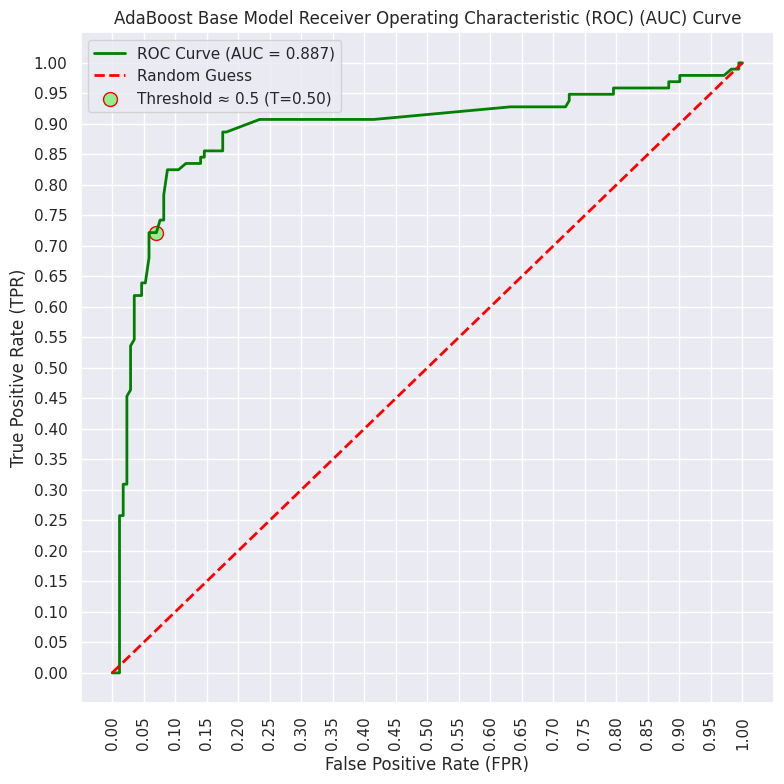

In [15]:
# Call the plot_roc_curve function with the actual labels and predicted probabilities
plot_roc_curve(
    y_actual_values=ytest,
    predicted_probability=adaboost_model_predictions_probabilities,
    title="AdaBoost Base Model"
)

# 12: 🌳 Visualizing a Specific Decision Tree in AdaBoost Model

In AdaBoost, each weak learner is a decision tree. The ensemble model consists of many such trees, and sometimes it's useful to visualize one of them to understand how the model is making decisions. Here, we will visualize a specific decision tree from the AdaBoost model (indexed at 15 in this case).


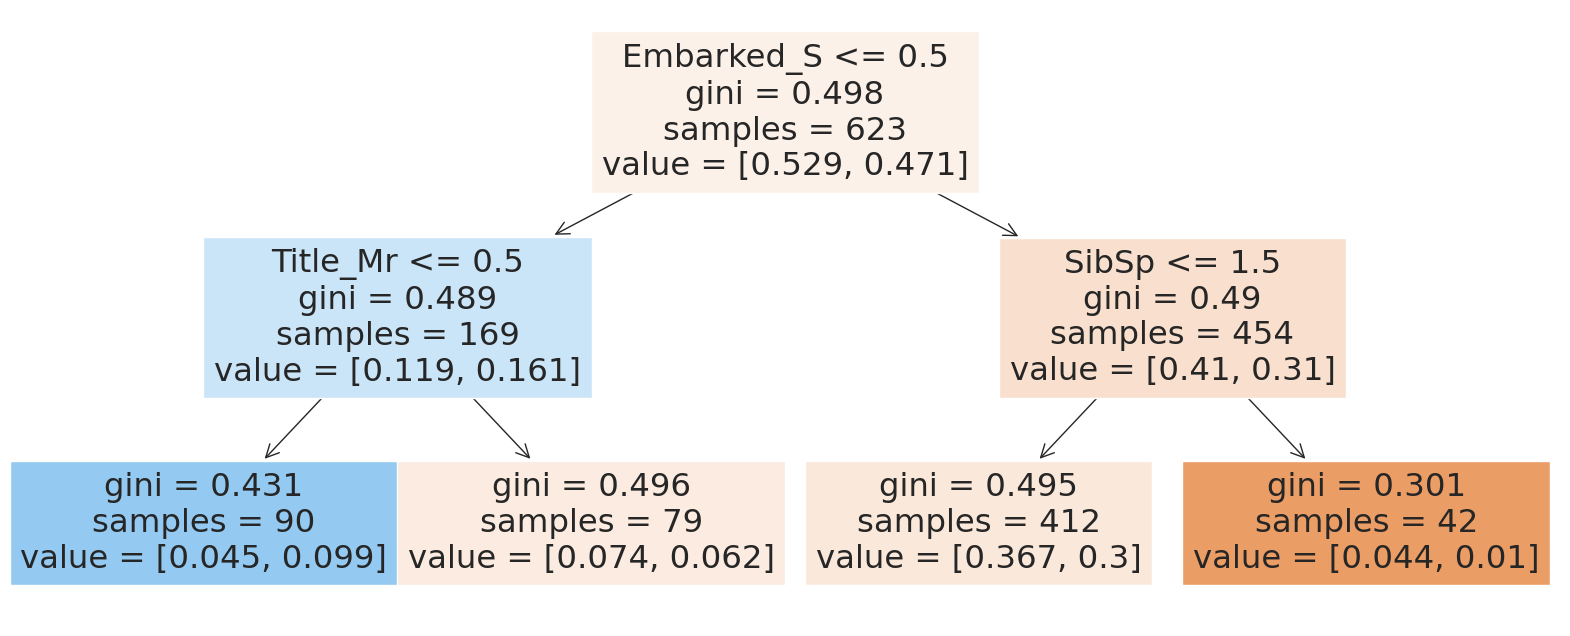

In [16]:
# Select a specific tree (index 15) from the Ada Boost model for visualization
selected_tree = adaboost_model.estimators_[15]

# Define visualization parameters
fig_size = (20, 8)  # Width and height in inches
resolution = 100    # DPI (dots per inch)
feature_list = list(X.columns)  # Get feature names from the dataset

# Create figure and axes for the visualization
fig, ax = plt.subplots(figsize=fig_size, dpi=resolution)

# Plot the decision tree with enhanced visualization
tree.plot_tree(
    decision_tree=selected_tree,  # The tree to visualize
    feature_names=feature_list,   # Names of features used in splits
    filled=True,                  # Color nodes by class
    ax=ax                         # The axes to plot on
)

# Display the visualization
plt.show()

# 12: **Final Selected Model for Predictions**

This model can be used for making predictions on new data without the need for retraining.


In [17]:
#your final slected model for predictions
final_model = adaboost_model

## 13: Load the CSV File into a DataFrame and Display the First Few Rows

To load a CSV file into a pandas DataFrame, we use the `pd.read_csv()` function. We can then create a copy of the DataFrame and display the first few rows to examine the structure of the dataset.


In [18]:
# Load the CSV file into a DataFrame
test = pd.read_csv('/kaggle/input/titanic-dataset/competition_clean.csv')

# Create a copy of the DataFrame
dataframe_test = test.copy()

# Display the first few rows of the dataset
dataframe_test.head()


,PassengerId,Pclass,Sex,SibSp,Parch,Embarked,Title,GrpSize,FareCat,AgeCat
0,892,3,male,0,0,Q,Mr,solo,0-10,32-48
1,893,3,female,1,0,S,Mrs,couple,0-10,32-48
2,894,2,male,0,0,Q,Mr,solo,0-10,48-64
3,895,3,male,0,0,S,Mr,solo,0-10,16-32
4,896,3,female,1,1,S,Mrs,group,10-25,16-32


## 14: Display the Shape of the DataFrame

To understand the dimensions of the dataset, we can use the `shape` attribute of the DataFrame. This returns the number of rows and columns in the dataset.


In [19]:
# Display the shape of the DataFrame (number of rows and columns)
dataframe_test.shape

(418, 10)

## 14.1: Perform One-Hot Encoding on Specified Categorical Columns

To convert categorical variables into a numerical format, we use One-Hot Encoding. This technique creates new binary columns for each category in the specified columns. After encoding, we convert all columns to integers for consistency.


In [20]:
# Perform One-Hot Encoding on specified categorical columns
dataframe_OneHot = pd.get_dummies(dataframe_test, columns=['Pclass', 'Sex', 'Embarked', 'Title', 'GrpSize', 'FareCat', 'AgeCat'])

# Convert the data type of all columns to integers (for consistency)
dataframe_OneHot = dataframe_OneHot.astype(int)

# Create a copy of the OneHot encoded DataFrame to preserve original data
dataframe_test = dataframe_OneHot.copy()

# Display the first few rows of the modified DataFrame
dataframe_test.head()

,PassengerId,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,...,FareCat_10-25,FareCat_100+,FareCat_25-40,FareCat_40-70,FareCat_70-100,AgeCat_0-16,AgeCat_16-32,AgeCat_32-48,AgeCat_48-64,AgeCat_64+
0,892,0,0,0,0,1,0,1,0,1,...,0,0,0,0,0,0,0,1,0,0
1,893,1,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,894,0,0,0,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,1,0
3,895,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
4,896,1,1,0,0,1,1,0,0,0,...,1,0,0,0,0,0,1,0,0,0


## 15: Extract and Drop the 'PassengerId' Column

In this step, we first extract the `PassengerId` column from the DataFrame, as it may be useful for identification purposes later. After extracting it, we drop the column from the DataFrame, since it is no longer needed for modeling.


In [21]:
# Extract 'PassengerId' column before dropping it
PassengerID = dataframe_test['PassengerId']

# Drop the 'PassengerId' column from the DataFrame as it's no longer needed for modeling
dataframe_test.drop('PassengerId', axis=1, inplace=True)

# Display the modified DataFrame after removing 'PassengerId'
dataframe_test.head()

,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,...,FareCat_10-25,FareCat_100+,FareCat_25-40,FareCat_40-70,FareCat_70-100,AgeCat_0-16,AgeCat_16-32,AgeCat_32-48,AgeCat_48-64,AgeCat_64+
0,0,0,0,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,1,0,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,1,1,0,0,1,1,0,0,0,1,...,1,0,0,0,0,0,1,0,0,0


## 16: Make Predictions Using the Trained Ada Boost Model

After preprocessing the test data, we can use the trained Ada Boost model to make predictions on the test set. The `predict()` function of the model is used to generate predictions.


In [22]:
# Use the trained Ada Boost model to make predictions on the processed test data
predictions_final = final_model.predict(dataframe_test)

# Display the predictions (optional, you can inspect the results)
print(predictions_final)

[0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 1 1 0 0 0 1 0 1 1 1 1 1 1 0 1 0 1 0 0 1 1
 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 0 1 1 0 0 0 0 0 0 0
 0 0 1 1 1 1 0 0 1 0 0 0 1 1 1 0 0 1 0 1 1 0 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0
 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1
 1 1 1 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 1 1 1 0 1 0 1 0 1 0 0 0 0 0 1 0 0 0 1
 1 0 1 0 0 1 1 1 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 1 0 1 0 1 1 0
 1 0 0 1 0 1 1 0 0 1 0 1 0 1 1 1 1 0 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0
 0 0 0 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1 0 1 1 0 0
 1 0 0 0 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0
 0 0 1 1 1 0 0 1 0 0 1]


## 17: Create a Submission DataFrame with 'PassengerId' and Predicted 'Survived' Values

To prepare the results for submission, we create a new DataFrame that includes the `PassengerId` and the model's predicted `Survived` values. This is typically done when preparing the output for competitions or evaluations.


In [23]:
# Create a DataFrame for the submission with 'PassengerId' and the predicted 'Survived' values
submission = pd.DataFrame({'PassengerId': PassengerID, 'Survived': predictions_final})

# Display the first few rows of the submission DataFrame to verify the structure
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


## 18: Display the Shape of the Submission DataFrame

To confirm the dimensions of the submission DataFrame, we use the `shape` attribute. This will give us the number of rows and columns in the DataFrame, ensuring the structure is as expected.


In [24]:
# Display the shape of the submission DataFrame
submission.shape

(418, 2)

## 19: Save the Submission DataFrame to a CSV File

After preparing the submission DataFrame, we save it as a CSV file without the index. This file can be used for submission or further analysis.


In [25]:
# Save the submission DataFrame to a CSV file without the index
submission.to_csv('submission.csv', index=False)

# Confirm the file has been saved (optional)
print("Submission file has been saved as 'submission.csv'")

Submission file has been saved as 'submission.csv'


# 👋 Muhammad Muhammad Mudasar Sabir

I’m a Machine Learning and Deep Learning enthusiast with a strong interest in Computer Vision and Generative AI. I enjoy solving real-world problems using intelligent, data-driven approaches. My focus areas include:

- 🤖 Machine Learning & Deep Learning  
- 🧠 Computer Vision & Generative Models  
- 📊 Data Analysis & Feature Engineering  
- 🚀 Model Evaluation & Deployment  

---

## 🔗 Connect with Me

- 🧠 **Kaggle**: [https://www.kaggle.com/mudasarsabir](https://www.kaggle.com/mudasarsabir)  
- 💻 **GitHub**: [https://github.com/mudasarsabir](https://github.com/mudasarsabir)  
- 🔗 **LinkedIn**: [https://www.linkedin.com/in/mudasarsabir](https://www.linkedin.com/in/mudasarsabir/)  
- 🌐 **Portfolio**: [https://muddasarsabir.netlify.app](https://muddasarsabir.netlify.app)

---

## 📌 Featured Project

### 🎯 Titanic Survival Prediction - Ada Boost
- GitHub: [View Repository](https://github.com/mudasarsabir/Titanic-Competition-By-AdaBoost-Classification)  
- Kaggle: [View Notebook](https://www.kaggle.com/code/mudasarsabir/titanic-competition-by-ada-boost)  

A beginner-friendly ML project applying Ada Boost classification to predict Titanic passenger survival, including EDA, preprocessing, and model evaluation.

---

## 📬 Get in Touch

I'm open to collaboration, research, and AI-focused opportunities. Let’s connect!
